<a href="https://colab.research.google.com/github/tripti369/Google_play_store/blob/main/Google_play_store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Use %matplotlib inline for Colab visualization
%matplotlib inline
warnings.filterwarnings('ignore')

# Load the datasets
# Ensure 'googleplaystore.csv' and 'googleplaystore_user_reviews.csv' are uploaded to your Colab session
df = pd.read_csv('googleplaystore.csv')
user_reviews_df = pd.read_csv('googleplaystore_user_reviews.csv')

# Basic exploration
print("Main Dataset Info:")
df.info()
print("\nFirst 5 rows of app data:")
display(df.head())

Main Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB

First 5 rows of app data:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
# Remove problematic row mentioned in instructions
df.drop(10472, axis=0, inplace=True)

# 1. Handle Missing Values
df['Rating'].fillna(df['Rating'].mean(), inplace=True)
df.dropna(subset=['App', 'Category', 'Type', 'Content Rating', 'Android Ver'], inplace=True)

# 2. Clean 'Reviews' (Convert to int)
df['Reviews'] = df['Reviews'].astype(int)

# 3. Clean 'Installs' (Remove '+' and ',', convert to int)
df['Installs'] = df['Installs'].str.replace('+', '').str.replace(',', '').astype(int)

# 4. Clean 'Price' (Remove '$', convert to float)
df['Price'] = df['Price'].str.replace('$', '').astype(float)

# 5. Clean 'Size' (Convert to bytes)
def convert_size(size):
    if 'M' in str(size):
        return float(size.replace('M', '')) * 1024 * 1024
    elif 'k' in str(size):
        return float(size.replace('k', '')) * 1024
    elif 'Varies with device' in str(size):
        return np.nan
    return size

df['Size_in_bytes'] = df['Size'].apply(convert_size)

print("\nData Cleaning Complete. Missing values remaining:")
print(df.isnull().sum())


Data Cleaning Complete. Missing values remaining:
App                  0
Category             0
Rating               0
Reviews              0
Size                 0
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          0
Size_in_bytes     1694
dtype: int64


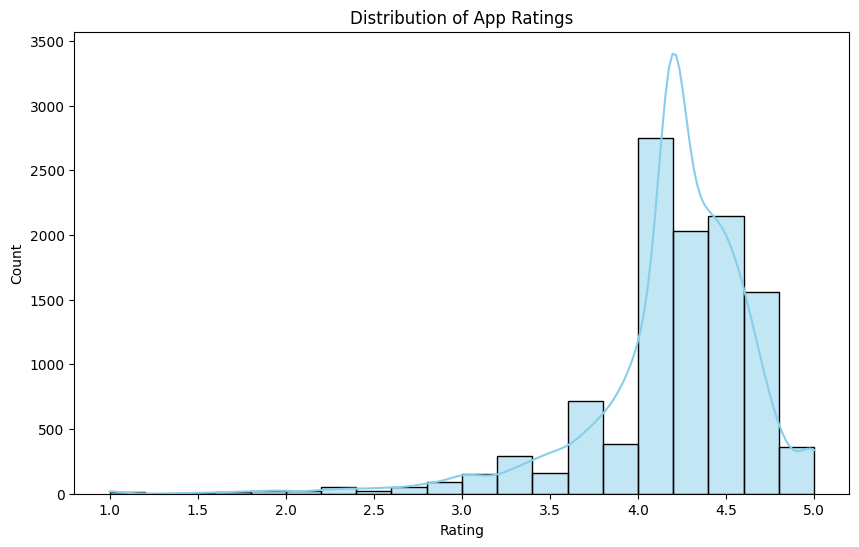

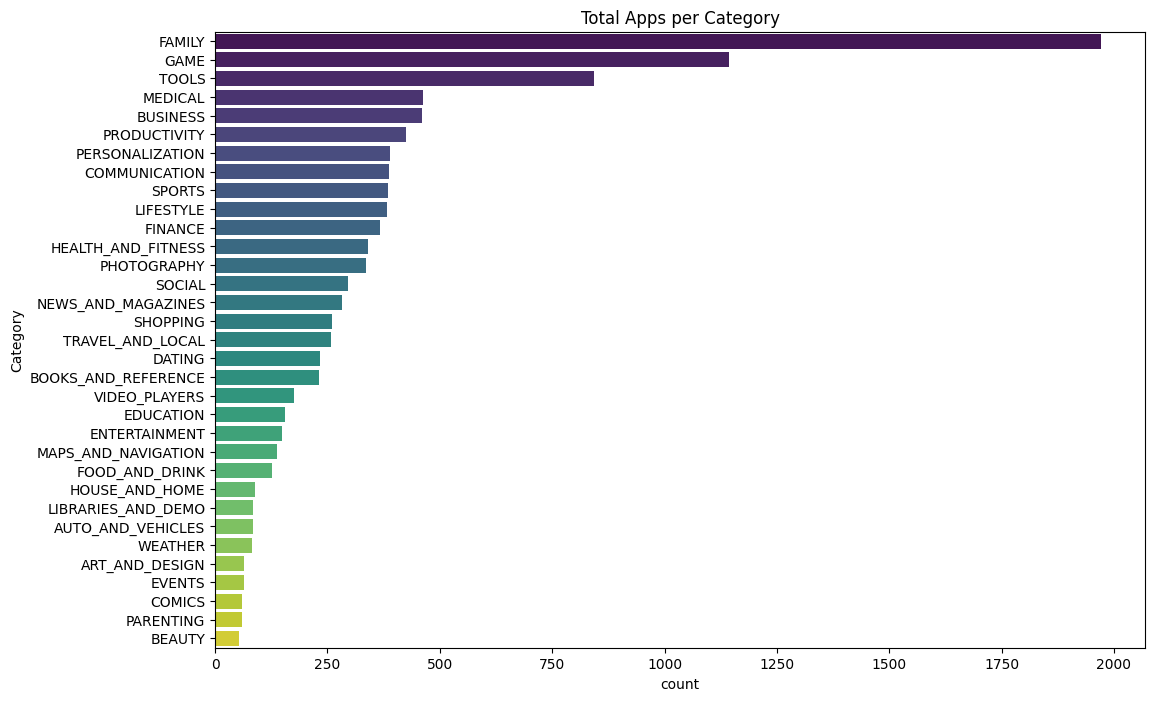

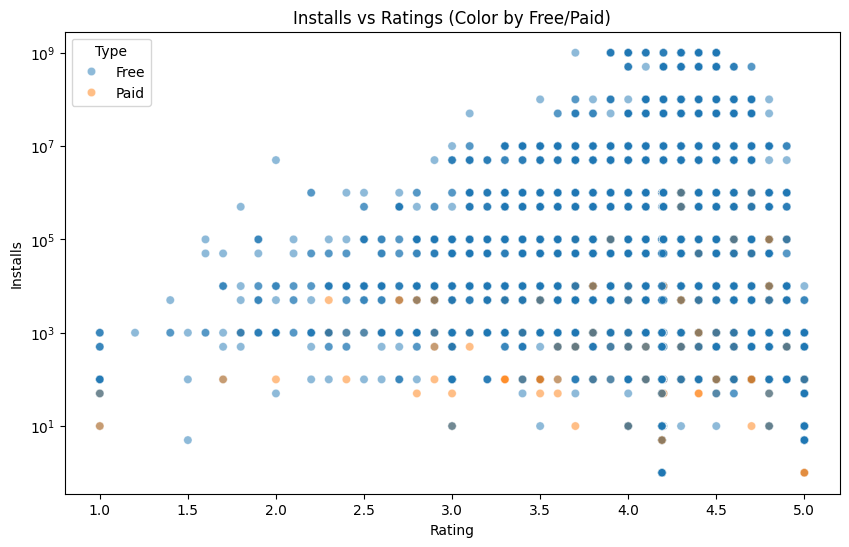

In [4]:
# Distribution of Ratings
plt.figure(figsize=(10, 6))
sns.histplot(df['Rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of App Ratings')
plt.show()

# Count of Apps by Category
plt.figure(figsize=(12, 8))
sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index, palette='viridis')
plt.title('Total Apps per Category')
plt.show()

# Relationship between Installs and Ratings
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Rating', y='Installs', hue='Type', data=df, alpha=0.5)
plt.yscale('log') # Use log scale for installs due to high variance
plt.title('Installs vs Ratings (Color by Free/Paid)')
plt.show()

In [5]:
# Average rating by category
avg_rating = df.groupby('Category')['Rating'].mean().sort_values(ascending=False)
print("\nTop 5 Categories by Average Rating:")
print(avg_rating.head(5))

# Most popular apps (by installs)
top_apps = df[['App', 'Installs']].sort_values(by='Installs', ascending=False).head(10)
print("\nTop 10 Most Installed Apps:")
print(top_apps)


Top 5 Categories by Average Rating:
Category
EDUCATION              4.387768
EVENTS                 4.363178
ART_AND_DESIGN         4.350389
BOOKS_AND_REFERENCE    4.310663
PERSONALIZATION        4.306557
Name: Rating, dtype: float64

Top 10 Most Installed Apps:
                     App    Installs
2611           Instagram  1000000000
3904  WhatsApp Messenger  1000000000
4153            Hangouts  1000000000
3565        Google Drive  1000000000
3765         Google News  1000000000
2604           Instagram  1000000000
3909           Instagram  1000000000
2545           Instagram  1000000000
3896      Subway Surfers  1000000000
451                Gmail  1000000000


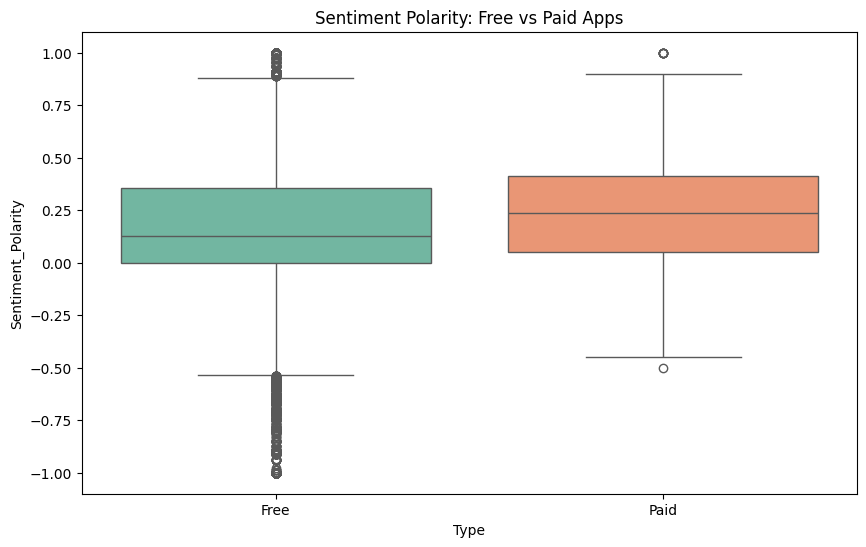


Top 5 Apps with Highest Average Positive Sentiment:
App
HomeWork                                             1.000000
Google Slides                                        0.933333
Daily Workouts - Exercise Fitness Routine Trainer    0.800000
Bed Time Fan - White Noise Sleep Sounds              0.781250
Cameringo Lite. Filters Camera                       0.770269
Name: Sentiment_Polarity, dtype: float64


In [6]:
# Merge main data with user reviews for sentiment insights
# Note: Sentiment columns are 'Sentiment', 'Sentiment_Polarity', and 'Sentiment_Subjectivity'
merged_df = pd.merge(df, user_reviews_df, on='App', how='inner')

# Visualize sentiment distribution by app type (Free vs Paid)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Type', y='Sentiment_Polarity', data=merged_df, palette='Set2')
plt.title('Sentiment Polarity: Free vs Paid Apps')
plt.show()

# Top 5 Apps with highest positive sentiment
positive_apps = merged_df.groupby('App')['Sentiment_Polarity'].mean().sort_values(ascending=False).head(5)
print("\nTop 5 Apps with Highest Average Positive Sentiment:")
print(positive_apps)